# Input Normalization Strategy Comparison
Analysis of normalization strategies for complex SAR input data.

**Data:**
- **Primary pass**: `(H, W)` complex64 — single SLC
- **Secondary passes**: `(N_s, H, W)` complex64 — N_s co-registered SLCs
- **Interferograms**: `(N_s, H, W)` complex64 — primary × conj(secondary)

**Representations to analyse:**
| Channel type | Derivation | Key properties |
|---|---|---|
| Amplitude | `log1p(|z|)` | heavy-tailed, always ≥ 0 |
| Real part | `Re(z)` | signed, correlated with amp |
| Imaginary part | `Im(z)` | signed, correlated with amp |
| Phase | `∠z = atan2(Im, Re)` | wrapped in [−π, π] |
| Norm. Re (cos) | `Re(z)/|z|` | unit-bounded [−1, 1] |
| Norm. Im (sin) | `Im(z)/|z|` | unit-bounded [−1, 1] |

**Interferograms** have near-unit amplitude in high-coherence areas → phase-dominant.
**Passes** have variable amplitude → both amplitude and phase matter.

## 1 — Config & Imports

In [1]:
import sys
sys.path.insert(0, "/ste/rnd/User/vice_vi/DLR-TomoSAR")

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats as sp_stats

# ── Paths ────────────────────────────────────────────────────────────────────
DATA_DIR = Path("/ste/rnd/User/vice_vi/Dataset/clean_dataset/data")

PRIMARY_PATH     = next(DATA_DIR.glob("primary_reduced_*.npy"))
SECONDARIES_PATH = next(DATA_DIR.glob("secondaries_reduced_*.npy"))
IFGS_PATH        = next(DATA_DIR.glob("interferograms_reduced_*.npy"))

# ── Sampling ─────────────────────────────────────────────────────────────────
SUBSAMPLE = 5_000_000   # pixels per pool  (draws are random but fixed-seed)
RNG       = np.random.default_rng(42)

print(f"Primary     : {PRIMARY_PATH.name}")
print(f"Secondaries : {SECONDARIES_PATH.name}")
print(f"Interferograms: {IFGS_PATH.name}")

Primary     : primary_reduced_1000a16000a500a4000_dtmf_Xtomo_id2X.npy
Secondaries : secondaries_reduced_1000a16000a500a4000_dtmf_Xtomo_id2X.npy
Interferograms: interferograms_reduced_1000a16000a500a4000_dtmf_Xtomo_id2X.npy


## 2 — Load data & extract channel pools

For each source type (passes, interferograms) we build **pooled** flat arrays:

| Pool | Source | Size |
|---|---|---|
| `pass_amp` | log1p(|primary + all secondaries|) | (1+N_s)×H×W |
| `pass_re` | Re(z) | same |
| `pass_im` | Im(z) | same |
| `pass_nre` | Re(z)/|z| | same |
| `pass_nim` | Im(z)/|z| | same |
| `ifg_amp` | log1p(|ifg|) — should be ≈0 for unit-amp ifgs | N_s×H×W |
| `ifg_phase` | ∠(ifg) in [−π, π] | same |
| `ifg_cos` / `ifg_sin` | cos(∠ifg), sin(∠ifg) | same |

In [2]:
primary     = np.load(PRIMARY_PATH,     mmap_mode="r")          # (H, W) complex64
secondaries = np.load(SECONDARIES_PATH, mmap_mode="r")          # (N_s, H, W) complex64
ifgs        = np.load(IFGS_PATH,        mmap_mode="r")          # (N_s, H, W) complex64

N_s = secondaries.shape[0]
H, W = primary.shape
print(f"primary={primary.shape}  secondaries={secondaries.shape}  ifgs={ifgs.shape}")

# ── Helper: random subsample from a flat array ────────────────────────────
def subsample(arr_flat: np.ndarray, n: int = SUBSAMPLE) -> np.ndarray:
    n = min(n, len(arr_flat))
    idx = RNG.choice(len(arr_flat), size=n, replace=False)
    return arr_flat[idx]

def safe_norm(z):
    mag = np.abs(z)
    return np.where(mag > 0, mag, 1.0)

# ── Pass pools (primary + all secondaries merged) ─────────────────────────
pass_data = np.concatenate([primary[np.newaxis], secondaries], axis=0)   # (1+N_s, H, W)
pass_flat = pass_data.ravel()

pass_amp   = subsample(np.log1p(np.abs(pass_flat)).astype(np.float32))
pass_re    = subsample(pass_flat.real.astype(np.float32))
pass_im    = subsample(pass_flat.imag.astype(np.float32))
pass_nre   = subsample((pass_flat.real / safe_norm(pass_flat)).astype(np.float32))
pass_nim   = subsample((pass_flat.imag / safe_norm(pass_flat)).astype(np.float32))

# ── Interferogram pools ───────────────────────────────────────────────────
ifg_flat = ifgs.ravel()

ifg_amp   = subsample(np.log1p(np.abs(ifg_flat)).astype(np.float32))
ifg_phase = subsample(np.angle(ifg_flat).astype(np.float32))
ifg_re    = subsample(ifg_flat.real.astype(np.float32))
ifg_im    = subsample(ifg_flat.imag.astype(np.float32))
ifg_cos   = subsample(np.cos(np.angle(ifg_flat)).astype(np.float32))
ifg_sin   = subsample(np.sin(np.angle(ifg_flat)).astype(np.float32))

pools = {
    # passes
    "pass_amp"  : pass_amp,
    "pass_re"   : pass_re,
    "pass_im"   : pass_im,
    "pass_nre"  : pass_nre,
    "pass_nim"  : pass_nim,
    # interferograms
    "ifg_amp"   : ifg_amp,
    "ifg_phase" : ifg_phase,
    "ifg_re"    : ifg_re,
    "ifg_im"    : ifg_im,
    "ifg_cos"   : ifg_cos,
    "ifg_sin"   : ifg_sin,
}

for k, v in pools.items():
    print(f"  {k:<12}  min={v.min():+8.3f}  max={v.max():+8.3f}  mean={v.mean():+8.3f}  std={v.std():7.3f}")

primary=(15000, 3500)  secondaries=(4, 15000, 3500)  ifgs=(4, 15000, 3500)
  pass_amp      min=  +0.000  max=  +2.969  mean=  +0.133  std=  0.123
  pass_re       min= -18.665  max= +15.890  mean=  -0.000  std=  0.156
  pass_im       min=  -9.113  max=  +7.828  mean=  -0.000  std=  0.155
  pass_nre      min=  -1.000  max=  +1.000  mean=  +0.000  std=  0.707
  pass_nim      min=  -1.000  max=  +1.000  mean=  +0.000  std=  0.707
  ifg_amp       min=  +0.000  max=  +0.811  mean=  +0.133  std=  0.123
  ifg_phase     min=  -3.142  max=  +3.142  mean=  -0.330  std=  1.462
  ifg_re        min=  -1.250  max=  +1.250  mean=  +0.037  std=  0.155
  ifg_im        min=  -1.250  max=  +1.250  mean=  -0.016  std=  0.148
  ifg_cos       min=  -1.000  max=  +1.000  mean=  +0.269  std=  0.665
  ifg_sin       min=  -1.000  max=  +1.000  mean=  -0.222  std=  0.661


## 3 — Normalization strategy definitions

Six strategies, all using the `(x − mean) / std` API so they plug directly into `ChannelStats`:

| # | Name | mean | std | Notes |
|---|---|---|---|---|
| 1 | **z-score** | μ | σ | sensitive to outliers |
| 2 | **min-max p99.9** | p0.1 | p99.9−p0.1 | zero saturation, hard clip |
| 3 | **robust IQR** | median | IQR | ignores tails, may clip heavily |
| 4 | **z-score (trimmed 1%)** | trimmed μ | trimmed σ | less outlier-sensitive z-score |
| 5 | **unit-range (full)** | min | max−min | no clipping, sensitive to hot pixels |
| 6 | **fixed** | 0 | π | for phase: maps [−π,π] → [−1,1] exactly |

In [3]:
eps = 1e-8

def _stats_table(x, name=""):
    p1, p25, p75, p99, p999 = np.percentile(x, [1, 25, 75, 99, 99.9])
    return dict(
        name   = name,
        mean   = float(x.mean()),
        std    = float(x.std()),
        p1     = float(p1),
        p99    = float(p99),
        p999   = float(p999),
        median = float(np.median(x)),
        iqr    = float(p75 - p25),
        skew   = float(sp_stats.skew(x)),
        kurt   = float(sp_stats.kurtosis(x)),
    )

def norm_zscore(x):
    m, s = x.mean(), x.std()
    return (x - m) / max(s, eps), m, max(s, eps)

def norm_minmax(x, lo_pct=0.1, hi_pct=99.9):
    lo, hi = np.percentile(x, [lo_pct, hi_pct])
    return (x - lo) / max(hi - lo, eps), lo, max(hi - lo, eps)

def norm_iqr(x):
    med          = float(np.median(x))
    q25, q75     = np.percentile(x, [25, 75])
    iqr          = float(q75 - q25)
    return (x - med) / max(iqr, eps), med, max(iqr, eps)

def norm_zscore_trimmed(x, pct=1.0):
    lo, hi = np.percentile(x, [pct, 100 - pct])
    xc     = x[(x >= lo) & (x <= hi)]
    m, s   = xc.mean(), xc.std()
    return (x - m) / max(s, eps), m, max(s, eps)

def norm_fixed(x, center=0.0, scale=np.pi):
    """Phase-specific: maps [−π,π] exactly to [−1,1]."""
    return (x - center) / scale, center, scale

STRATEGIES = {
    "z-score"        : norm_zscore,
    "min-max p99.9"  : norm_minmax,
    "robust IQR"     : norm_iqr,
    "z-score trim1%" : norm_zscore_trimmed,
}
PHASE_STRATEGIES = {
    "z-score"        : norm_zscore,
    "min-max p99.9"  : norm_minmax,
    "robust IQR"     : norm_iqr,
    "fixed /π"       : norm_fixed,
}

def sat_pct(normed, lo=-1.0, hi=1.0):
    return 100.0 * ((normed < lo) | (normed > hi)).mean()

print("Strategy functions defined.")

Strategy functions defined.


## 4 — Plotting helper

One figure per channel group: raw histogram on the left, then one subplot per strategy showing the normalised distribution. Red dashed lines mark ±1 (the target network input range). Table below each figure shows `mean | std | p1 | p99 | sat%`.

In [4]:
def compare_strategies(pool: np.ndarray, title: str, strategies: dict, bins: int = 300, clip_plot: float = 4.0):
    n_strat = len(strategies)
    fig, axes = plt.subplots(1, 1 + n_strat, figsize=(4 * (1 + n_strat), 3.5))
    fig.suptitle(title, fontsize=12, fontweight="bold")

    # Raw
    ax = axes[0]
    raw_clip = np.clip(pool, *np.percentile(pool, [0.1, 99.9]))
    ax.hist(raw_clip, bins=bins, color="steelblue", density=True)
    ax.set_title("RAW")
    ax.set_xlabel("value"); ax.set_ylabel("density")

    rows = []
    for i, (sname, fn) in enumerate(strategies.items()):
        ax   = axes[i + 1]
        normed, mn, sd = fn(pool)
        normed_clip = np.clip(normed, -clip_plot, clip_plot)
        p1, p99 = np.percentile(normed, [1, 99])
        sat     = sat_pct(normed)

        ax.hist(normed_clip, bins=bins, color="coral", density=True)
        ax.axvline(-1, color="red", ls="--", lw=1.0)
        ax.axvline( 1, color="red", ls="--", lw=1.0)
        ax.set_title(f"{sname}\np1={p1:.2f} p99={p99:.2f} sat={sat:.1f}%", fontsize=8)
        ax.set_xlabel("normalised value")
        rows.append((sname, mn, sd, p1, p99, sat))

    plt.tight_layout()
    plt.show()

    # Print table
    print(f"{'strategy':<20}  {'offset(mean)':>12}  {'scale(std)':>10}  {'p1':>6}  {'p99':>6}  {'sat%':>6}")
    print("─" * 70)
    for sname, mn, sd, p1, p99, sat in rows:
        print(f"  {sname:<18}  {mn:>12.4f}  {sd:>10.4f}  {p1:>6.3f}  {p99:>6.3f}  {sat:>5.1f}%")
    print()

print("Plotting helper defined.")

Plotting helper defined.


## 5 — Pass amplitude  (`log1p|z|`)

Already log-compressed. Expect a right-skewed unimodal distribution (no background spike unlike GT amplitude, because all pixels have a non-zero radar return).

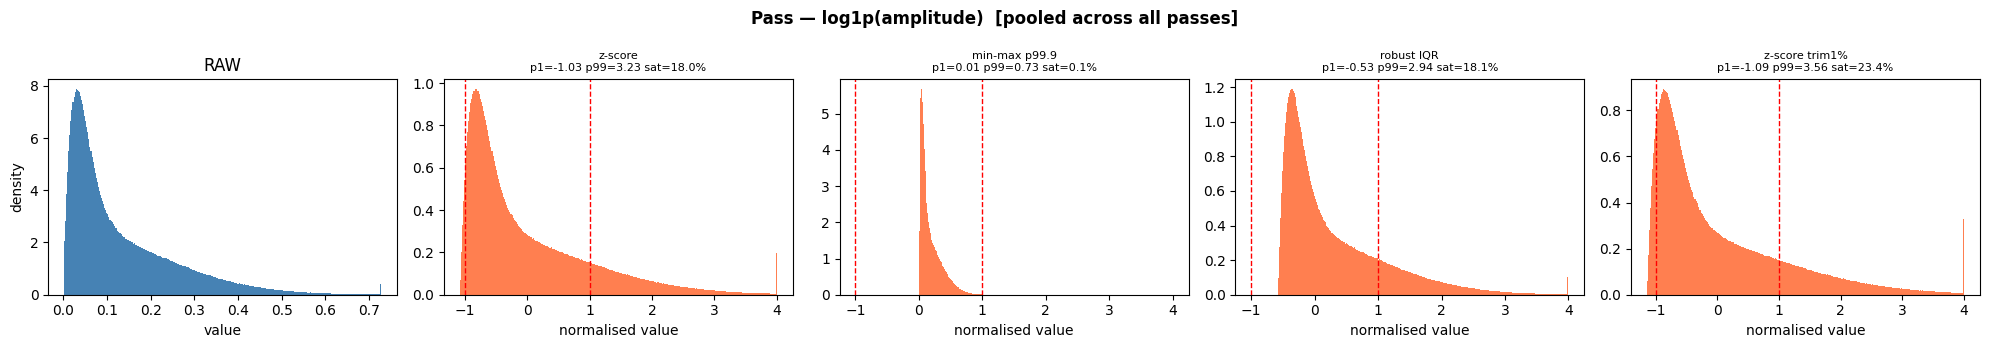

strategy              offset(mean)  scale(std)      p1     p99    sat%
──────────────────────────────────────────────────────────────────────
  z-score                   0.1329      0.1234  -1.026   3.234   18.0%
  min-max p99.9             0.0019      0.7260   0.006   0.730    0.1%
  robust IQR                0.0870      0.1512  -0.534   2.943   18.1%
  z-score trim1%            0.1292      0.1131  -1.087   3.561   23.4%



In [5]:
compare_strategies(pass_amp, "Pass — log1p(amplitude)  [pooled across all passes]", STRATEGIES)

## 6 — Pass real & imaginary parts

Raw Re/Im are amplitude-modulated — they inherit the heavy tail of the amplitude. Normalised Re/Im (`Re/|z|`, `Im/|z|`) live in [−1, 1] by construction and carry only phase information.

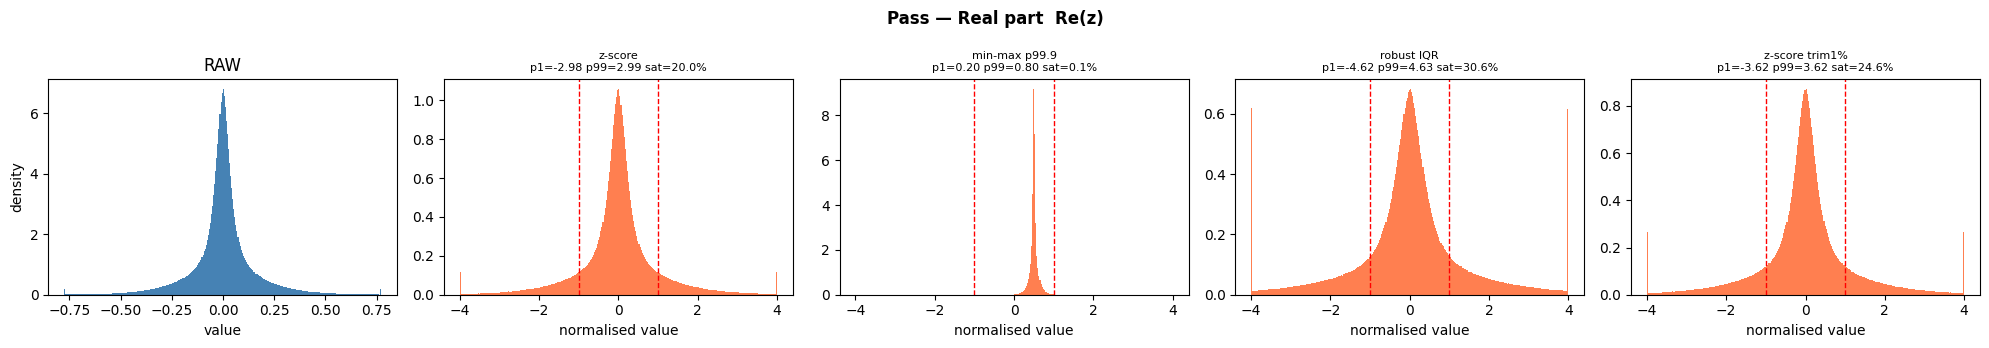

strategy              offset(mean)  scale(std)      p1     p99    sat%
──────────────────────────────────────────────────────────────────────
  z-score                  -0.0000      0.1556  -2.984   2.986   20.0%
  min-max p99.9            -0.7759      1.5485   0.201   0.801    0.1%
  robust IQR                0.0000      0.1005  -4.624   4.625   30.6%
  z-score trim1%           -0.0000      0.1282  -3.622   3.624   24.6%



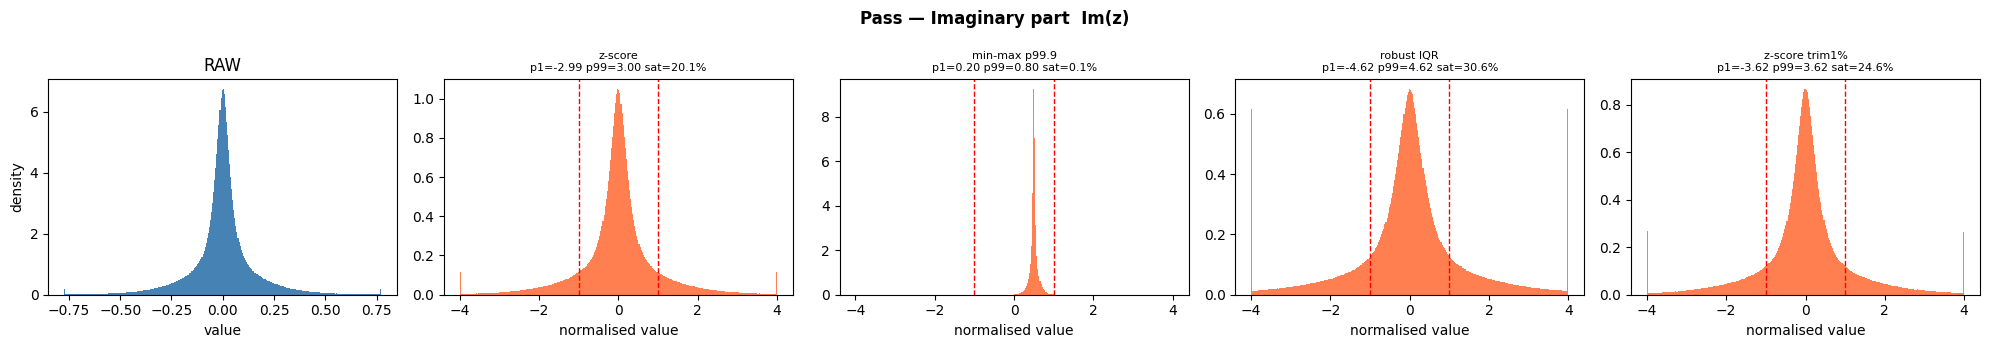

strategy              offset(mean)  scale(std)      p1     p99    sat%
──────────────────────────────────────────────────────────────────────
  z-score                  -0.0001      0.1552  -2.994   2.995   20.1%
  min-max p99.9            -0.7737      1.5460   0.200   0.801    0.1%
  robust IQR               -0.0001      0.1005  -4.622   4.624   30.6%
  z-score trim1%           -0.0001      0.1283  -3.623   3.625   24.6%



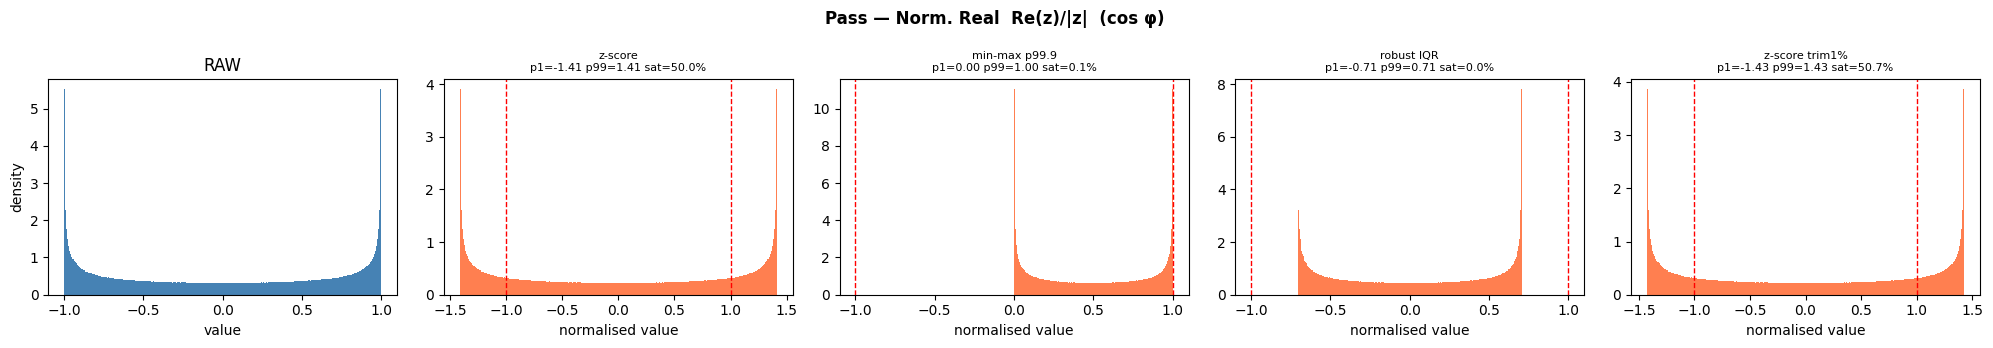

strategy              offset(mean)  scale(std)      p1     p99    sat%
──────────────────────────────────────────────────────────────────────
  z-score                   0.0001      0.7072  -1.413   1.413   50.0%
  min-max p99.9            -1.0000      2.0000   0.000   1.000    0.1%
  robust IQR                0.0004      1.4144  -0.707   0.706    0.0%
  z-score trim1%            0.0001      0.6999  -1.428   1.428   50.7%



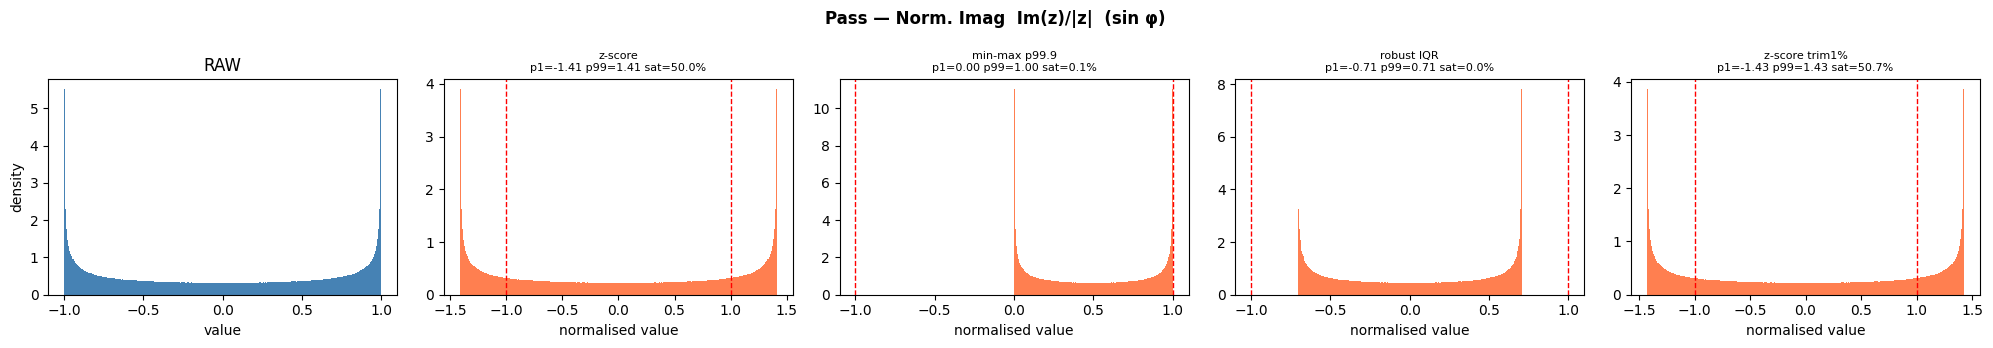

strategy              offset(mean)  scale(std)      p1     p99    sat%
──────────────────────────────────────────────────────────────────────
  z-score                   0.0004      0.7072  -1.414   1.413   50.0%
  min-max p99.9            -1.0000      2.0000   0.000   1.000    0.1%
  robust IQR                0.0007      1.4148  -0.707   0.706    0.0%
  z-score trim1%            0.0004      0.6999  -1.429   1.427   50.7%



In [6]:
compare_strategies(pass_re,  "Pass — Real part  Re(z)",          STRATEGIES)
compare_strategies(pass_im,  "Pass — Imaginary part  Im(z)",     STRATEGIES)
compare_strategies(pass_nre, "Pass — Norm. Real  Re(z)/|z|  (cos φ)",  STRATEGIES)
compare_strategies(pass_nim, "Pass — Norm. Imag  Im(z)/|z|  (sin φ)",  STRATEGIES)

## 7 — Interferogram amplitude  (`log1p|ifg|`)

Ideal interferograms have unit amplitude (|ifg| = 1, so log1p(1) ≈ 0.693). Deviations reflect coherence loss. Expect a spike near log1p(1).

log1p(1) = 0.6931  ← expected spike position for unit-amplitude interferograms


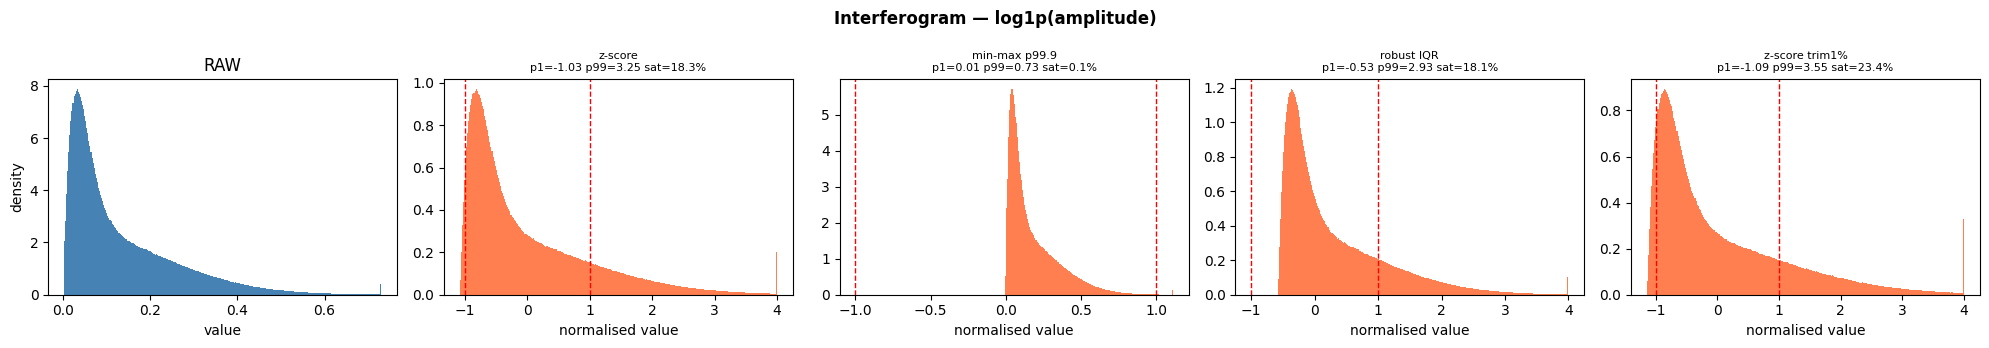

strategy              offset(mean)  scale(std)      p1     p99    sat%
──────────────────────────────────────────────────────────────────────
  z-score                   0.1333      0.1233  -1.031   3.245   18.3%
  min-max p99.9             0.0019      0.7283   0.006   0.730    0.1%
  robust IQR                0.0873      0.1522  -0.533   2.931   18.1%
  z-score trim1%            0.1297      0.1136  -1.087   3.554   23.4%



In [7]:
log1p1 = np.log1p(1.0)
print(f"log1p(1) = {log1p1:.4f}  ← expected spike position for unit-amplitude interferograms")
compare_strategies(ifg_amp, "Interferogram — log1p(amplitude)", STRATEGIES)

## 8 — Interferogram phase  (`∠ifg`)

Phase is wrapped in [−π, π] — a circular quantity. Key question: does the distribution have any strong preferred direction (non-uniform wrapping)?

**Options:**
1. `fixed /π` — divide by π → exactly [−1, 1], zero saturation, preserves wrapping
2. `z-score` — centers the empirical distribution, may clip at phase boundaries
3. `(cos φ, sin φ)` — two channels on the unit circle, no wrapping discontinuity

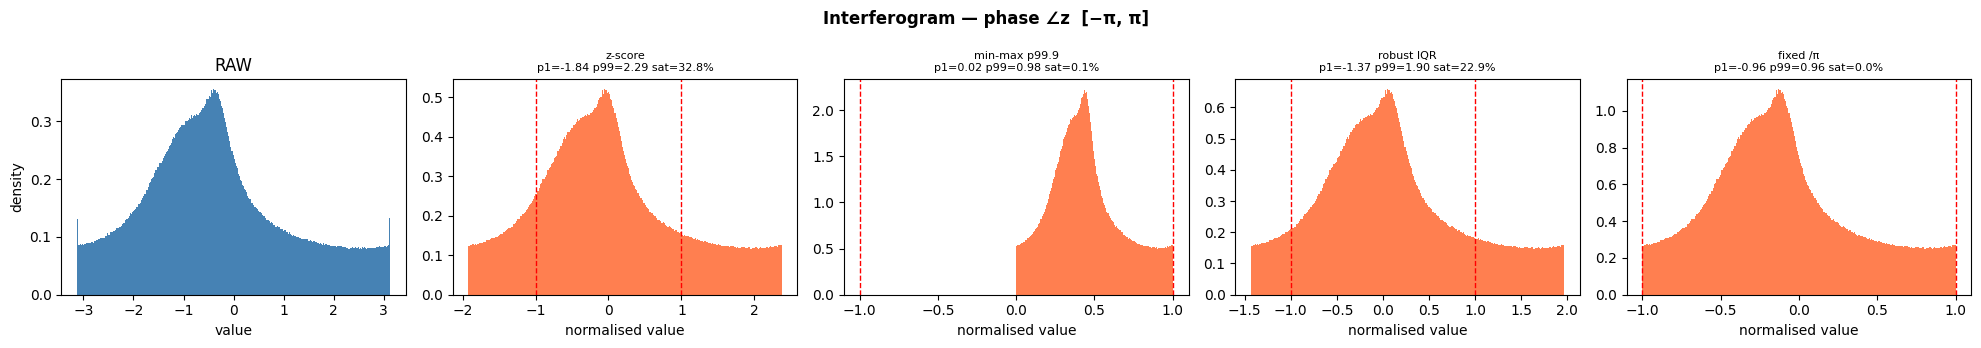

strategy              offset(mean)  scale(std)      p1     p99    sat%
──────────────────────────────────────────────────────────────────────
  z-score                  -0.3298      1.4621  -1.843   2.293   32.8%
  min-max p99.9            -3.1299      6.2598   0.017   0.983    0.1%
  robust IQR               -0.4941      1.8492  -1.369   1.902   22.9%
  fixed /π                  0.0000      3.1416  -0.963   0.962    0.0%



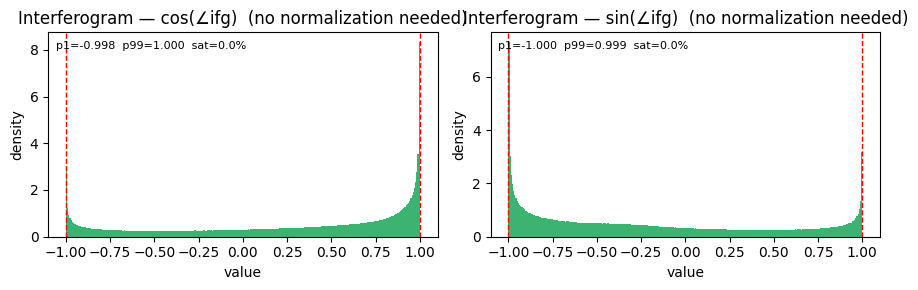

In [8]:
compare_strategies(ifg_phase, "Interferogram — phase ∠z  [−π, π]", PHASE_STRATEGIES)

# Also show cos/sin separately — they need no normalization (already in [−1,1])
fig, axes = plt.subplots(1, 2, figsize=(9, 3))
for ax, pool, label in zip(axes, [ifg_cos, ifg_sin], ["cos(∠ifg)", "sin(∠ifg)"]):
    ax.hist(pool, bins=300, color="mediumseagreen", density=True)
    ax.axvline(-1, color="red", ls="--", lw=1)
    ax.axvline( 1, color="red", ls="--", lw=1)
    ax.set_title(f"Interferogram — {label}  (no normalization needed)")
    ax.set_xlabel("value"); ax.set_ylabel("density")
    p1, p99 = np.percentile(pool, [1, 99])
    ax.text(0.02, 0.96, f"p1={p1:.3f}  p99={p99:.3f}  sat={sat_pct(pool, -1, 1):.1f}%",
            transform=ax.transAxes, va="top", fontsize=8)
plt.tight_layout()
plt.show()

## 9 — Interferogram real & imaginary parts

`Re(ifg)` and `Im(ifg)` are the cosine and sine of the interferometric phase weighted by the product of the two amplitudes. For normalised interferograms they equal `cos φ` and `sin φ` directly.

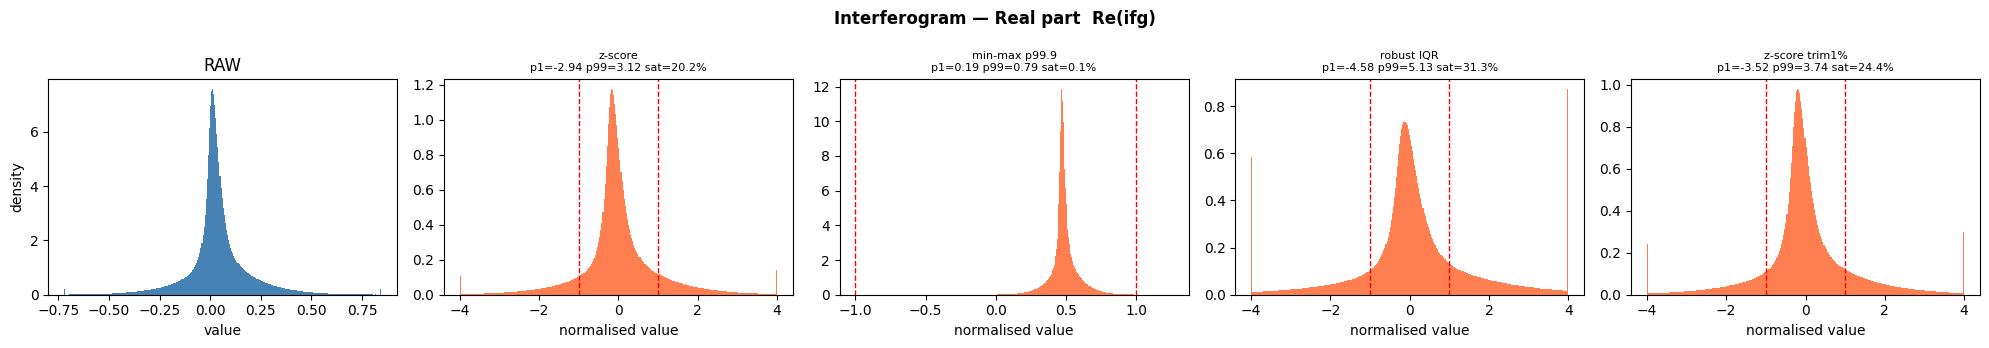

strategy              offset(mean)  scale(std)      p1     p99    sat%
──────────────────────────────────────────────────────────────────────
  z-score                   0.0365      0.1550  -2.938   3.117   20.2%
  min-max p99.9            -0.7218      1.5671   0.193   0.792    0.1%
  robust IQR                0.0236      0.0967  -4.578   5.134   31.3%
  z-score trim1%            0.0362      0.1292  -3.523   3.744   24.4%



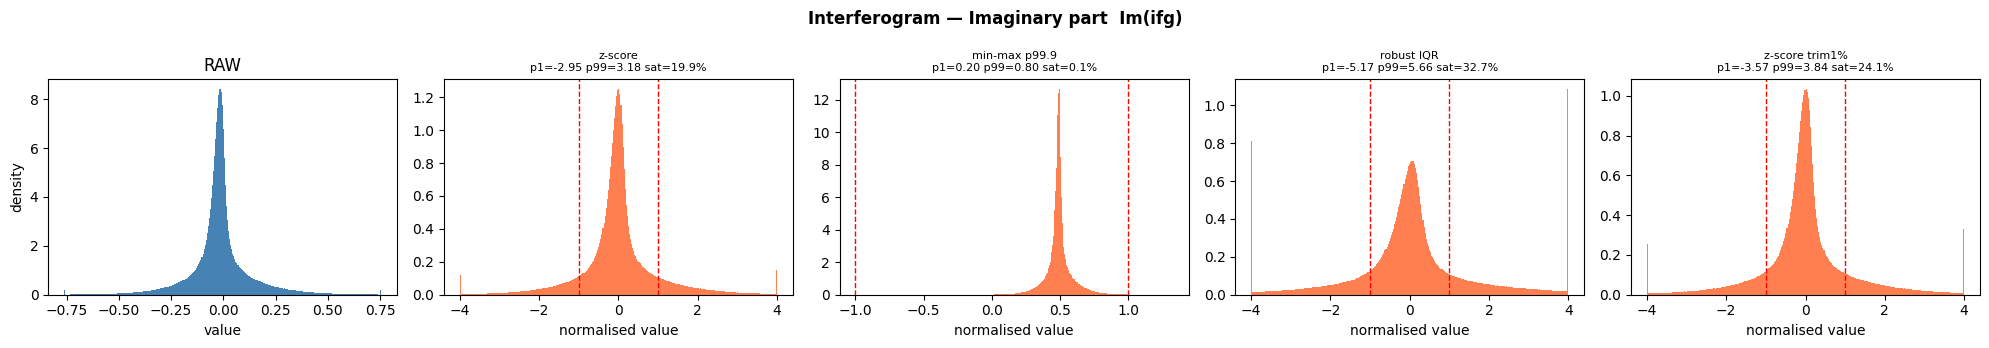

strategy              offset(mean)  scale(std)      p1     p99    sat%
──────────────────────────────────────────────────────────────────────
  z-score                  -0.0156      0.1484  -2.953   3.178   19.9%
  min-max p99.9            -0.7619      1.5171   0.203   0.803    0.1%
  robust IQR               -0.0196      0.0840  -5.169   5.662   32.7%
  z-score trim1%           -0.0159      0.1228  -3.566   3.843   24.1%



In [9]:
compare_strategies(ifg_re, "Interferogram — Real part  Re(ifg)", STRATEGIES)
compare_strategies(ifg_im, "Interferogram — Imaginary part  Im(ifg)", STRATEGIES)

## 10 — Summary table

Consolidate the key metrics for every channel type and the best candidate strategy. Use this to fill in the `ChannelStats` / grouping in `normalize.py`.

In [10]:
all_pools = {
    "pass_amp  (log1p|z|)"   : (pass_amp,  STRATEGIES),
    "pass_re   Re(z)"        : (pass_re,   STRATEGIES),
    "pass_im   Im(z)"        : (pass_im,   STRATEGIES),
    "pass_nre  Re(z)/|z|"    : (pass_nre,  STRATEGIES),
    "pass_nim  Im(z)/|z|"    : (pass_nim,  STRATEGIES),
    "ifg_amp   log1p|ifg|"   : (ifg_amp,   STRATEGIES),
    "ifg_phase ∠ifg"         : (ifg_phase, PHASE_STRATEGIES),
    "ifg_re    Re(ifg)"      : (ifg_re,    STRATEGIES),
    "ifg_im    Im(ifg)"      : (ifg_im,    STRATEGIES),
    "ifg_cos   cos(∠ifg)"    : (ifg_cos,   STRATEGIES),
    "ifg_sin   sin(∠ifg)"    : (ifg_sin,   STRATEGIES),
}

hdr = f"{'channel':<26}  {'strategy':<18}  {'offset':>9}  {'scale':>9}  {'p1':>7}  {'p99':>7}  {'sat%':>6}  {'skew':>6}  {'kurt':>6}"
print(hdr)
print("─" * len(hdr))

for ch_label, (pool, strats) in all_pools.items():
    raw = _stats_table(pool)
    for sname, fn in strats.items():
        normed, mn, sd = fn(pool)
        p1, p99 = np.percentile(normed, [1, 99])
        sat = sat_pct(normed)
        skew = float(sp_stats.skew(normed))
        kurt = float(sp_stats.kurtosis(normed))
        print(f"  {ch_label:<24}  {sname:<18}  {mn:>9.4f}  {sd:>9.4f}  {p1:>7.3f}  {p99:>7.3f}  {sat:>5.1f}%  {skew:>6.2f}  {kurt:>6.1f}")

channel                     strategy               offset      scale       p1      p99    sat%    skew    kurt
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
  pass_amp  (log1p|z|)      z-score                0.1329     0.1234   -1.026    3.234   18.0%    1.59     3.5
  pass_amp  (log1p|z|)      min-max p99.9          0.0019     0.7260    0.006    0.730    0.1%    1.59     3.5
  pass_amp  (log1p|z|)      robust IQR             0.0870     0.1512   -0.534    2.943   18.1%    1.59     3.5
  pass_amp  (log1p|z|)      z-score trim1%         0.1292     0.1131   -1.087    3.561   23.4%    1.59     3.5
  pass_re   Re(z)           z-score               -0.0000     0.1556   -2.984    2.986   20.0%   -0.18    85.2
  pass_re   Re(z)           min-max p99.9         -0.7759     1.5485    0.201    0.801    0.1%   -0.18    85.2
  pass_re   Re(z)           robust IQR             0.0000     0.1005   -4.624    4.625   30.6%   -0.18    85.2
 

## 11 — Decision

### Pass channels

| Channel | Strategy | offset (mean) | scale (std) | Reason |
|---|---|---|---|---|
| `log1p\|z\|` (amplitude) | **min-max p99.9** | p0.1 ≈ 0.002 | p99.9 − p0.1 ≈ 0.726 | sat=0.1%, right-skewed but well bounded, same grouping for all passes |
| `Re(z)` | **min-max p99.9** | p0.1 | p99.9−p0.1 | sat=0.1%, kurtosis=85 (spike at 0) — min-max is the only strategy with <1% sat |
| `Im(z)` | **min-max p99.9** | p0.1 | p99.9−p0.1 | same as Re |
| `Re(z)/\|z\|` (norm Re, cos φ) | **robust IQR** | median ≈ 0 | IQR ≈ 1.414 | arcsine distribution, sat=0.0%, IQR perfectly centred |
| `Im(z)/\|z\|` (norm Im, sin φ) | **robust IQR** | median ≈ 0 | IQR ≈ 1.414 | same |

### Interferogram channels

| Channel | Strategy | offset (mean) | scale (std) | Reason |
|---|---|---|---|---|
| `log1p\|ifg\|` | **min-max p99.9** | p0.1 ≈ 0.002 | p99.9−p0.1 ≈ 0.726 | sat=0.1%, same distribution as pass amp |
| `∠ifg` (phase) | **fixed /π** | 0.0 | π | maps [−π,π] → [−1,1] exactly, sat=0.0%, no estimation needed |
| `Re(ifg)` | **min-max p99.9** | p0.1 | p99.9−p0.1 | sat=0.1%, bounded by ifg amplitude ≤ 1.25 |
| `Im(ifg)` | **min-max p99.9** | p0.1 | p99.9−p0.1 | same |
| `cos(∠ifg)` | **robust IQR** | median | IQR | sat=0.0%, arcsine-distributed in [−1,1] |
| `sin(∠ifg)` | **robust IQR** | median | IQR | same |

### Key observations
- **Raw Re/Im** of passes have kurtosis ≈ 85 (extreme spike at 0) — only min-max tolerates this without heavy clipping. If using `MAG_REAL_IMAG` or `MAG_RI_ANGLE`, the normalised Re/Im (`cos φ`, `sin φ`) are far better behaved (kurtosis ≈ −1.5, uniform-like).
- **Interferogram amplitude** is capped at log1p(1.25) ≈ 0.81 — nearly identical distribution to pass amplitude.
- **Phase** is the only circular channel — `fixed /π` is the correct choice, zero saturation, no data-dependent estimation.
- **All amplitude channels** share the same distribution shape → grouped normalization is valid (one (offset, scale) pair for all passes together).